## Import Google drive, setup library and label names

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageStat
from collections import Counter
import itertools

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

BASE_DIR  = "/content/drive/MyDrive/kaggle_dataset/shezhenv3-txt"
IMAGE_DIR = f"{BASE_DIR}/images"
CSV_PATH  = f"{BASE_DIR}/tongue_dataset.csv"

LABEL_NAMES = ["Coating White", "Coating Yellow", "Texture_None", "Texture_Geographic", "Texture_Cracked", "Texture_Dentate"]

print("Setup done")


Mounted at /content/drive
✓ Setup done


## Load CSV File

In [ ]:
df = pd.read_csv(CSV_PATH)

LABEL_NAMES = ["Coating White", "Coating Yellow", "Texture_None", "Texture_Geographic", "Texture_Cracked", "Texture_Dentate"]

df.columns = ["filename"] + LABEL_NAMES
label_cols = LABEL_NAMES

print(f"✓ Shape       : {df.shape}")
print(f"  Label cols  : {label_cols}")
print(f"  Missing     : {df.isnull().sum().sum()}")
print(f"  Duplicates  : {df.duplicated('filename').sum()}")
df.head(6)

✓ Shape       : (3193, 7)
  Label cols  : ['Coating White', 'Coating Yellow', 'Texture_None', 'Texture_Geographic', 'Texture_Cracked', 'Texture_Dentate']
  Missing     : 0
  Duplicates  : 0


,filename,Coating White,Coating Yellow,Texture_None,Texture_Geographic,Texture_Cracked,Texture_Dentate
0,10010.jpg,1,0,1,0,0,0
1,10013.jpg,0,1,0,0,1,0
2,10020.jpg,1,0,0,0,1,0
3,10025.jpg,1,0,1,0,0,0
4,10027.jpg,1,0,0,0,1,0
5,10028.jpg,1,0,1,0,0,0


## label คู่ไหนอยู่ด้วยกันบ่อยที่สุด

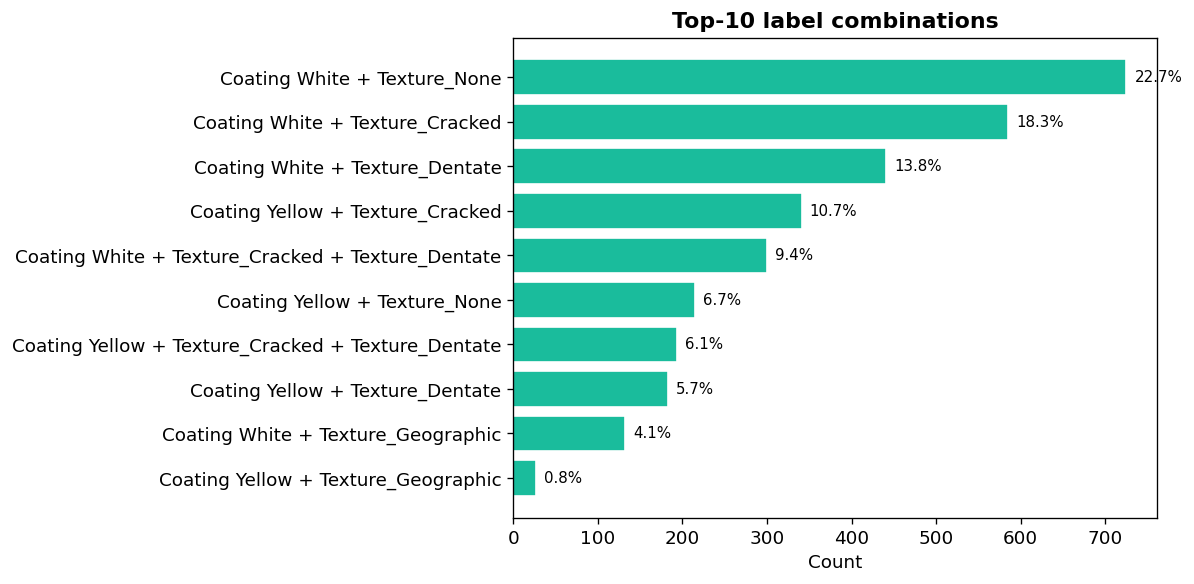

,combination,count,pct
0,Coating White + Texture_None,725,22.7%
1,Coating White + Texture_Cracked,585,18.3%
2,Coating White + Texture_Dentate,441,13.8%
3,Coating Yellow + Texture_Cracked,341,10.7%
4,Coating White + Texture_Cracked + Texture_Dentate,300,9.4%
5,Coating Yellow + Texture_None,215,6.7%
6,Coating Yellow + Texture_Cracked + Texture_Dentate,194,6.1%
7,Coating Yellow + Texture_Dentate,183,5.7%
8,Coating White + Texture_Geographic,132,4.1%
9,Coating Yellow + Texture_Geographic,27,0.8%


In [ ]:
combos = [tuple(r) for r in labels]
combo_cnt = Counter(combos)

rows = []
for combo, cnt_v in combo_cnt.most_common(15):
    active = [label_cols[i] for i, v in enumerate(combo) if v == 1]
    rows.append({
        "combination": " + ".join(active) if active else "(none)",
        "count": cnt_v,
        "pct": f"{cnt_v/N*100:.1f}%",
        "raw": combo
    })

cdf = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cdf["combination"][:10][::-1], cdf["count"][:10][::-1], color="#1abc9c", edgecolor="white")
ax.set_title("Top-10 label combinations", fontweight="bold")
ax.set_xlabel("Count")

for i, (v, p) in enumerate(zip(cdf["count"][:10][::-1], cdf["pct"][:10][::-1])):
    ax.text(v + N*0.003, i, p, va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/eda_combinations.png", bbox_inches="tight")
plt.show()

pd.set_option('display.max_colwidth', None)

display(cdf.drop(columns="raw"))

## เช็คว่ามีรูปที่ label โดนแค่ 0 หรือ 1 ครั้ง

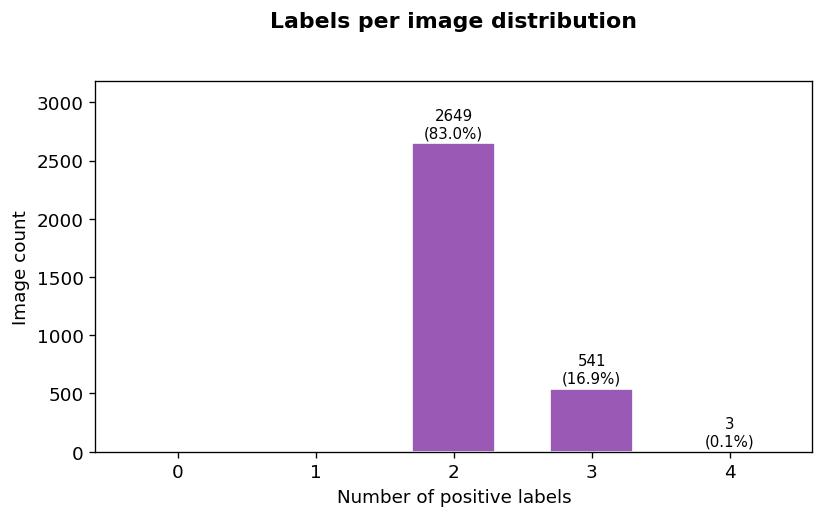

In [ ]:
label_cols = ["Coating White", "Coating Yellow", "Texture_None", "Texture_Geographic", "Texture_Cracked", "Texture_Dentate"]
labels = df[label_cols].values.astype(int)
N = len(df)

label_counts = labels.sum(axis=1)
cnt = Counter(label_counts)

fig, ax = plt.subplots(figsize=(7, 4.5))

keys = sorted(cnt.keys())
vals = [cnt[k] for k in keys]

ax.bar(keys, vals, color="#9b59b6", edgecolor="white", width=0.6)

ax.set_title("Labels per image distribution", fontweight="bold", y=1.12)
ax.set_xlabel("Number of positive labels")
ax.set_ylabel("Image count")

all_ticks = [0, 1, 2, 3, 4]
ax.set_xticks(all_ticks)
ax.set_xlim(-0.6, 4.6)

ax.set_ylim(0, max(vals) * 1.2)

for k, v in zip(keys, vals):
    ax.text(k, v + 25, f"{v}\n({v/N*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/eda_label_count.png", bbox_inches="tight")
plt.show()

เช็คว่าทั้งกลุ่ม Coating และ Texture ได้รับการ Label เรียบร้อยแล้ว

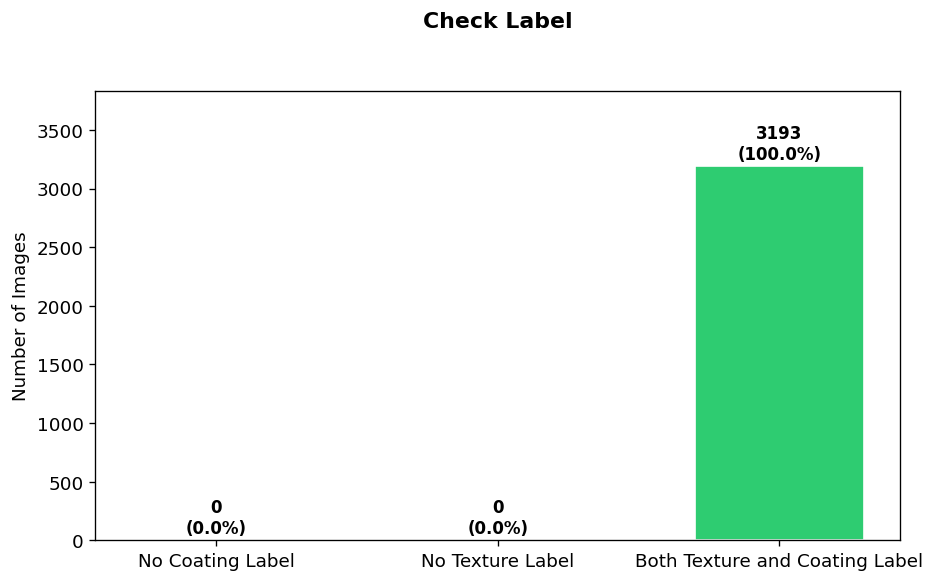

In [ ]:
import matplotlib.pyplot as plt

no_coating = df[(df["Coating White"] == 0) & (df["Coating Yellow"] == 0)]

texture_cols = ["Texture_None", "Texture_Geographic", "Texture_Cracked", "Texture_Dentate"]
no_texture = df[(df[texture_cols] == 0).all(axis=1)]

has_coating = (df["Coating White"] == 1) | (df["Coating Yellow"] == 1)
has_texture = (df[texture_cols] == 1).any(axis=1)
both_labeled = df[has_coating & has_texture]

group_names = [
    "No Coating Label",
    "No Texture Label",
    "Both Texture and Coating Label"
]
group_counts = [len(no_coating), len(no_texture), len(both_labeled)]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(group_names, group_counts, color=colors, edgecolor="white", width=0.6)

ax.set_title("Check Label", fontweight="bold", y=1.12)
ax.set_ylabel("Number of Images")

ax.set_ylim(0, max(group_counts) * 1.2)

for bar in bars:
    height = bar.get_height()
    percentage = (height / len(df)) * 100
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 25,
        f"{height}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## เช็คว่า Class ไหนโดน Label บ่อยที่สุด

In [ ]:
label_cols = ["Coating White", "Coating Yellow", "Texture_None", "Texture_Geographic", "Texture_Cracked", "Texture_Dentate"]

class_counts = df[label_cols].sum().reset_index()
class_counts.columns = ["Class Name", "Count"]

class_counts["Percentage"] = (class_counts["Count"] / len(df) * 100).round(1)
class_counts["Percentage"] = class_counts["Percentage"].astype(str) + "%"

print(f"📊 สรุปจำนวนข้อมูลราย Class (จากทั้งหมด {len(df)} รูป):")
class_counts.sort_values(by="Count", ascending=False).reset_index(drop=True)

📊 สรุปจำนวนข้อมูลราย Class (จากทั้งหมด 3193 รูป):


,Class Name,Count,Percentage
0,Coating White,2220,69.5%
1,Texture_Cracked,1460,45.7%
2,Texture_Dentate,1131,35.4%
3,Coating Yellow,973,30.5%
4,Texture_None,940,29.4%
5,Texture_Geographic,209,6.5%
